In [279]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Ibrahim\Desktop\RESUME_PROJECT_2.xlsx")

df.head()

,REF_DATE,GEO,DGUID,Type of employee,Estimate,North American Industry Classification System (NAICS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2001-01,Canada,2021A000011124,Employees paid by the hour,Employment,Industrial aggregate excluding unclassified bu...,Persons,249,units,0,v54027108,1.2.1.2,6639210.0,NaN,NaN,NaN,0
1,2001-01,Canada,2021A000011124,Employees paid by the hour,Employment,Goods producing industries [11-33N],Persons,249,units,0,v54027100,1.2.1.3,1843560.0,NaN,NaN,NaN,0
2,2001-01,Canada,2021A000011124,Employees paid by the hour,Employment,"Forestry, logging and support [11N]",Persons,249,units,0,v54027116,1.2.1.4,38427.0,NaN,NaN,NaN,0
3,2001-01,Canada,2021A000011124,Employees paid by the hour,Employment,"Mining, quarrying, and oil and gas extraction ...",Persons,249,units,0,v54027124,1.2.1.10,59378.0,NaN,NaN,NaN,0
4,2001-01,Canada,2021A000011124,Employees paid by the hour,Employment,Utilities [22],Persons,249,units,0,v54027132,1.2.1.17,40582.0,NaN,NaN,NaN,0


In [280]:
df.shape

(63648, 17)

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63648 entries, 0 to 63647
Data columns (total 17 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               63648 non-null  object 
 1   GEO                                                    63648 non-null  object 
 2   DGUID                                                  63648 non-null  object 
 3   Type of employee                                       63648 non-null  object 
 4   Estimate                                               63648 non-null  object 
 5   North American Industry Classification System (NAICS)  63648 non-null  object 
 6   UOM                                                    63648 non-null  object 
 7   UOM_ID                                                 63648 non-null  int64  
 8   SCALAR_FACTOR                                 

In [282]:
df["Estimate"].unique()

array(['Employment', 'Average weekly earnings including overtime',
       'Average hourly earnings including overtime',
       'Average weekly hours'], dtype=object)

In [283]:
df["Type of employee"].unique()

array(['Employees paid by the hour',
       'Salaried employees paid a fixed salary'], dtype=object)

In [284]:
df["GEO"].unique()

array(['Canada'], dtype=object)

In [285]:
df["North American Industry Classification System (NAICS)"].unique()

array(['Industrial aggregate excluding unclassified businesses [11-91N]',
       'Goods producing industries [11-33N]',
       'Forestry, logging and support [11N]',
       'Mining, quarrying, and oil and gas extraction [21]',
       'Utilities [22]', 'Construction [23]', 'Manufacturing [31-33]',
       'Non-durable goods [311N]', 'Durable goods [321N]',
       'Service producing industries [41-91N]', 'Trade [41-45N]',
       'Wholesale trade [41]', 'Retail trade [44-45]',
       'Transportation and warehousing [48-49]',
       'Information and cultural industries [51]',
       'Finance and insurance [52]',
       'Real estate and rental and leasing [53]',
       'Professional, scientific and technical services [54]',
       'Management of companies and enterprises [55]',
       'Administrative and support, waste management and remediation services [56]',
       'Educational services [61]',
       'Health care and social assistance [62]',
       'Arts, entertainment and recreation [71]

In [286]:
df["REF_DATE"].min()

'2001-01'

In [287]:
df["REF_DATE"].max()

'2026-06'

In [288]:
df["REF_DATE"].nunique()

306

In [289]:
df["Estimate"].value_counts()

Estimate
Employment                                    15912
Average weekly earnings including overtime    15912
Average hourly earnings including overtime    15912
Average weekly hours                          15912
Name: count, dtype: int64

In [290]:
df["Type of employee"].value_counts()

Type of employee
Employees paid by the hour                31824
Salaried employees paid a fixed salary    31824
Name: count, dtype: int64

In [291]:
df.groupby("Estimate")["VALUE"].apply(lambda x: x.isna().sum())

Estimate
Average hourly earnings including overtime    701
Average weekly earnings including overtime    701
Average weekly hours                          701
Employment                                    714
Name: VALUE, dtype: int64

In [292]:
missing = df[df["VALUE"].isna()]

missing[["REF_DATE", "Type of employee", "Estimate",
         "North American Industry Classification System (NAICS)"]].head(20)

,REF_DATE,Type of employee,Estimate,North American Industry Classification System (NAICS)
15,2001-01,Employees paid by the hour,Employment,Finance and insurance [52]
16,2001-01,Employees paid by the hour,Employment,Real estate and rental and leasing [53]
25,2001-01,Employees paid by the hour,Employment,Public administration [91]
41,2001-01,Employees paid by the hour,Average weekly earnings including overtime,Finance and insurance [52]
42,2001-01,Employees paid by the hour,Average weekly earnings including overtime,Real estate and rental and leasing [53]
51,2001-01,Employees paid by the hour,Average weekly earnings including overtime,Public administration [91]
67,2001-01,Employees paid by the hour,Average hourly earnings including overtime,Finance and insurance [52]
68,2001-01,Employees paid by the hour,Average hourly earnings including overtime,Real estate and rental and leasing [53]
77,2001-01,Employees paid by the hour,Average hourly earnings including overtime,Public administration [91]
93,2001-01,Employees paid by the hour,Average weekly hours,Finance and insurance [52]


In [293]:
missing.groupby("REF_DATE").size().head(20)

REF_DATE
2001-01    24
2001-02    24
2001-03    24
2001-04    24
2001-05    24
2001-06    24
2001-07    24
2001-08    24
2001-09    24
2001-10    24
2001-11    24
2001-12    24
2002-01     8
2002-02     8
2002-03     8
2002-04     8
2002-05     8
2002-06     8
2002-07     8
2002-08     8
dtype: int64

In [294]:
missing["REF_DATE"].unique()

array(['2001-01', '2001-02', '2001-03', '2001-04', '2001-05', '2001-06',
       '2001-07', '2001-08', '2001-09', '2001-10', '2001-11', '2001-12',
       '2002-01', '2002-02', '2002-03', '2002-04', '2002-05', '2002-06',
       '2002-07', '2002-08', '2002-09', '2002-10', '2002-11', '2002-12',
       '2003-01', '2003-02', '2003-03', '2003-04', '2003-05', '2003-06',
       '2003-07', '2003-08', '2003-09', '2003-10', '2003-11', '2003-12',
       '2004-01', '2004-02', '2004-03', '2004-04', '2004-05', '2004-06',
       '2004-07', '2004-08', '2004-09', '2004-10', '2004-11', '2004-12',
       '2005-01', '2005-02', '2005-03', '2005-04', '2005-05', '2005-06',
       '2005-07', '2005-08', '2005-09', '2005-10', '2005-11', '2005-12',
       '2006-01', '2006-02', '2006-03', '2006-04', '2006-05', '2006-06',
       '2006-07', '2006-08', '2006-09', '2006-10', '2006-11', '2006-12',
       '2007-01', '2007-02', '2007-03', '2007-04', '2007-05', '2007-06',
       '2007-07', '2007-08', '2007-09', '2007-10', 

In [295]:
missing.groupby("REF_DATE").size().value_counts().sort_index()

8     264
9      10
12      1
16     16
17      2
24     12
25      1
Name: count, dtype: int64

In [296]:
missing.groupby(
    "North American Industry Classification System (NAICS)"
).size().sort_values(ascending=False)

North American Industry Classification System (NAICS)
Public administration [91]                      2448
Utilities [22]                                   104
Finance and insurance [52]                        97
Real estate and rental and leasing [53]           96
Information and cultural industries [51]          40
Forestry, logging and support [11N]               17
Management of companies and enterprises [55]      11
Wholesale trade [41]                               4
dtype: int64

In [297]:
df.duplicated().sum()

np.int64(0)

In [298]:
df.duplicated(
    subset=[
        "REF_DATE",
        "GEO",
        "Type of employee",
        "Estimate",
        "North American Industry Classification System (NAICS)"
    ]
).sum()

np.int64(0)

In [299]:
df = df.drop(columns=["SYMBOL", "TERMINATED"])

In [300]:
df.shape

(63648, 15)

In [301]:
df.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'Type of employee',
 'Estimate',
 'North American Industry Classification System (NAICS)',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'DECIMALS']

In [302]:
df[["UOM", "SCALAR_FACTOR", "DECIMALS"]].drop_duplicates()

,UOM,SCALAR_FACTOR,DECIMALS
0,Persons,units,0
26,Dollars,units,2
78,Hours,units,1


In [303]:
df["STATUS"].value_counts(dropna=False)

STATUS
A      26315
NaN    19008
B      12498
F       2625
C       2269
D        567
x        192
E        174
Name: count, dtype: int64

In [304]:
df.groupby("STATUS", dropna=False)["VALUE"].agg(
    ["count", "min", "max"]
)

,count,min,max
STATUS,,,
A,26315,11.96,10416600.0
B,12498,14.00,10855163.0
C,2269,13.20,1872806.0
D,567,14.40,695094.0
E,174,29.95,555260.0
F,0,NaN,NaN
x,0,NaN,NaN
NaN,19008,9.01,8480854.0


In [305]:
df[df["VALUE"].isna()]["STATUS"].value_counts(dropna=False)

STATUS
F    2625
x     192
Name: count, dtype: int64

In [306]:
df["VALUE"].isna().mean() * 100

np.float64(4.425904977375565)

In [307]:
df["Estimate"].unique()

array(['Employment', 'Average weekly earnings including overtime',
       'Average hourly earnings including overtime',
       'Average weekly hours'], dtype=object)

In [308]:
estimate_map = {
    "Employment": "Employment",
    "Average weekly earnings including overtime": "Weekly_Earnings",
    "Average hourly earnings including overtime": "Hourly_Earnings",
    "Average weekly hours": "Weekly_Hours"
}

df["Estimate"] = df["Estimate"].map(estimate_map)

In [309]:
df["Estimate"].unique()

array(['Employment', 'Weekly_Earnings', 'Hourly_Earnings', 'Weekly_Hours'],
      dtype=object)

In [310]:
df_wide = df.pivot(
    index=[
        "REF_DATE",
        "GEO",
        "Type of employee",
        "North American Industry Classification System (NAICS)"
    ],
    columns="Estimate",
    values="VALUE"
).reset_index()

In [311]:
df_wide.head(20)

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
0,2001-01,Canada,Employees paid by the hour,Accommodation and food services [72],723233.0,9.53,233.85,24.8
1,2001-01,Canada,Employees paid by the hour,"Administrative and support, waste management a...",306287.0,12.63,412.07,32.5
2,2001-01,Canada,Employees paid by the hour,"Arts, entertainment and recreation [71]",142765.0,12.75,296.07,23.1
3,2001-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6
4,2001-01,Canada,Employees paid by the hour,Durable goods [321N],820768.0,19.17,750.06,39.1
5,2001-01,Canada,Employees paid by the hour,Educational services [61],16557.0,16.71,368.25,22.5
6,2001-01,Canada,Employees paid by the hour,Finance and insurance [52],NaN,NaN,NaN,NaN
7,2001-01,Canada,Employees paid by the hour,"Forestry, logging and support [11N]",38427.0,21.37,831.11,38.8
8,2001-01,Canada,Employees paid by the hour,Goods producing industries [11-33N],1843560.0,19.28,738.12,38.2
9,2001-01,Canada,Employees paid by the hour,Health care and social assistance [62],1039202.0,19.02,542.52,28.5


In [312]:
df_wide.shape

(15912, 8)

In [313]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15912 entries, 0 to 15911
Data columns (total 8 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               15912 non-null  object 
 1   GEO                                                    15912 non-null  object 
 2   Type of employee                                       15912 non-null  object 
 3   North American Industry Classification System (NAICS)  15912 non-null  object 
 4   Employment                                             15198 non-null  float64
 5   Hourly_Earnings                                        15211 non-null  float64
 6   Weekly_Earnings                                        15211 non-null  float64
 7   Weekly_Hours                                           15211 non-null  float64
dtypes: float64(4), object(4)
memory usage: 994.6+ K

In [314]:
df_wide.isna().sum()

Estimate
REF_DATE                                                   0
GEO                                                        0
Type of employee                                           0
North American Industry Classification System (NAICS)      0
Employment                                               714
Hourly_Earnings                                          701
Weekly_Earnings                                          701
Weekly_Hours                                             701
dtype: int64

In [315]:
df_wide[df_wide.isna().any(axis=1)].head(10)

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
6,2001-01,Canada,Employees paid by the hour,Finance and insurance [52],NaN,NaN,NaN,NaN
18,2001-01,Canada,Employees paid by the hour,Public administration [91],NaN,NaN,NaN,NaN
19,2001-01,Canada,Employees paid by the hour,Real estate and rental and leasing [53],NaN,NaN,NaN,NaN
32,2001-01,Canada,Salaried employees paid a fixed salary,Finance and insurance [52],NaN,NaN,NaN,NaN
44,2001-01,Canada,Salaried employees paid a fixed salary,Public administration [91],NaN,NaN,NaN,NaN
45,2001-01,Canada,Salaried employees paid a fixed salary,Real estate and rental and leasing [53],NaN,NaN,NaN,NaN
58,2001-02,Canada,Employees paid by the hour,Finance and insurance [52],NaN,NaN,NaN,NaN
70,2001-02,Canada,Employees paid by the hour,Public administration [91],NaN,NaN,NaN,NaN
71,2001-02,Canada,Employees paid by the hour,Real estate and rental and leasing [53],NaN,NaN,NaN,NaN
84,2001-02,Canada,Salaried employees paid a fixed salary,Finance and insurance [52],NaN,NaN,NaN,NaN


In [316]:
df_wide.dropna().shape

(15198, 8)

In [317]:
df_wide.shape[0] - df_wide.dropna().shape[0]

714

In [318]:
df_wide[[
    "Employment",
    "Hourly_Earnings",
    "Weekly_Earnings",
    "Weekly_Hours"
]].describe()

Estimate,Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
count,1.519800e+04,15211.000000,15211.000000,15211.000000
mean,9.134783e+05,28.862083,1041.269021,35.109677
std,1.760124e+06,9.906978,443.001840,5.239252
min,2.161000e+03,9.010000,203.310000,13.200000
25%,1.143035e+05,21.755000,730.595000,31.500000
50%,2.621480e+05,27.540000,1005.330000,37.100000
75%,7.196468e+05,34.430000,1302.610000,38.800000
max,1.085516e+07,73.450000,2936.090000,48.000000


In [319]:
df_wide["North American Industry Classification System (NAICS)"].value_counts()

North American Industry Classification System (NAICS)
Accommodation and food services [72]                                          612
Administrative and support, waste management and remediation services [56]    612
Utilities [22]                                                                612
Transportation and warehousing [48-49]                                        612
Trade [41-45N]                                                                612
Service producing industries [41-91N]                                         612
Retail trade [44-45]                                                          612
Real estate and rental and leasing [53]                                       612
Public administration [91]                                                    612
Professional, scientific and technical services [54]                          612
Other services (except public administration) [81]                            612
Non-durable goods [311N]                    

In [320]:
df_wide["REF_DATE"] = pd.to_datetime(df_wide["REF_DATE"])

In [321]:
df_wide["REF_DATE"].dtype

dtype('<M8[ns]')

In [322]:
df_wide["North American Industry Classification System (NAICS)"].unique()

array(['Accommodation and food services [72]',
       'Administrative and support, waste management and remediation services [56]',
       'Arts, entertainment and recreation [71]', 'Construction [23]',
       'Durable goods [321N]', 'Educational services [61]',
       'Finance and insurance [52]',
       'Forestry, logging and support [11N]',
       'Goods producing industries [11-33N]',
       'Health care and social assistance [62]',
       'Industrial aggregate excluding unclassified businesses [11-91N]',
       'Information and cultural industries [51]',
       'Management of companies and enterprises [55]',
       'Manufacturing [31-33]',
       'Mining, quarrying, and oil and gas extraction [21]',
       'Non-durable goods [311N]',
       'Other services (except public administration) [81]',
       'Professional, scientific and technical services [54]',
       'Public administration [91]',
       'Real estate and rental and leasing [53]', 'Retail trade [44-45]',
       'Service 

In [323]:
overall_employment = df_wide[
    (df_wide["North American Industry Classification System (NAICS)"] ==
     "Industrial aggregate excluding unclassified businesses [11-91N]")
]

In [324]:
overall_employment.head()

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
10,2001-01-01,Canada,Employees paid by the hour,Industrial aggregate excluding unclassified bu...,6639210.0,16.25,514.23,31.6
36,2001-01-01,Canada,Salaried employees paid a fixed salary,Industrial aggregate excluding unclassified bu...,4610538.0,23.11,863.51,37.4
62,2001-02-01,Canada,Employees paid by the hour,Industrial aggregate excluding unclassified bu...,6684118.0,16.14,509.81,31.6
88,2001-02-01,Canada,Salaried employees paid a fixed salary,Industrial aggregate excluding unclassified bu...,4657171.0,23.01,860.80,37.3
114,2001-03-01,Canada,Employees paid by the hour,Industrial aggregate excluding unclassified bu...,6676047.0,16.17,510.65,31.5


In [325]:
overall_employment.shape

(612, 8)

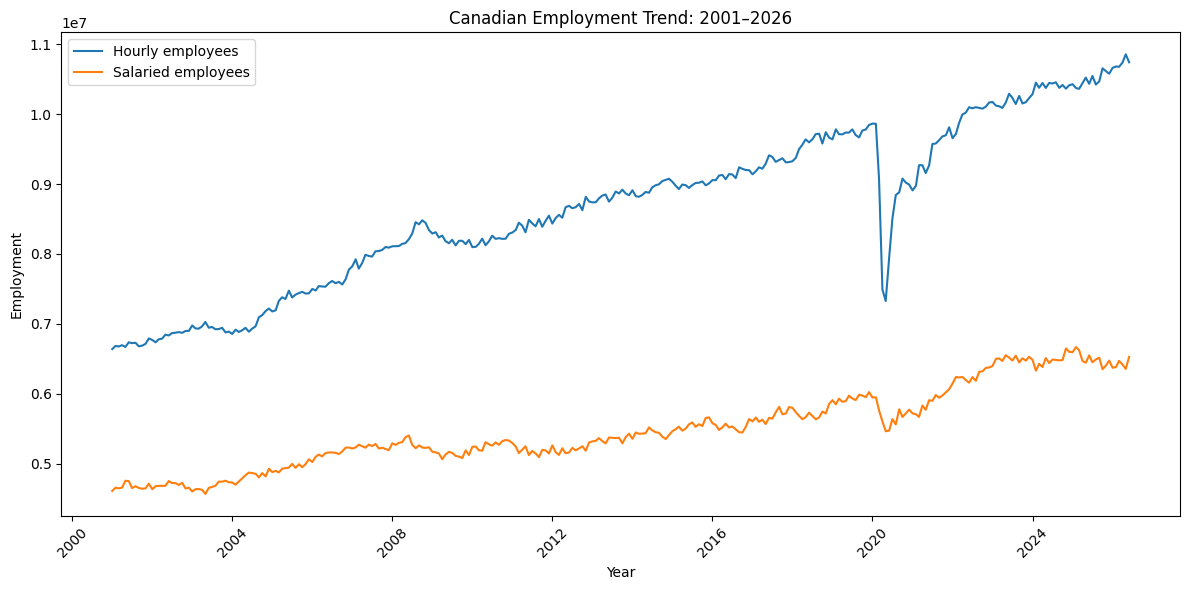

In [326]:
import matplotlib.pyplot as plt

hourly = overall_employment[
    overall_employment["Type of employee"] == "Employees paid by the hour"
]

salaried = overall_employment[
    overall_employment["Type of employee"] == "Salaried employees paid a fixed salary"
]

plt.figure(figsize=(12, 6))

plt.plot(
    hourly["REF_DATE"],
    hourly["Employment"],
    label="Hourly employees"
)

plt.plot(
    salaried["REF_DATE"],
    salaried["Employment"],
    label="Salaried employees"
)

plt.xlabel("Year")
plt.ylabel("Employment")
plt.title("Canadian Employment Trend: 2001–2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [327]:
industry_employment = (
    df_wide.groupby(
        "North American Industry Classification System (NAICS)"
    )["Employment"]
    .mean()
    .sort_values(ascending=False)
)

In [328]:
industry_employment

North American Industry Classification System (NAICS)
Industrial aggregate excluding unclassified businesses [11-91N]               7.081101e+06
Service producing industries [41-91N]                                         5.733457e+06
Goods producing industries [11-33N]                                           1.347644e+06
Trade [41-45N]                                                                1.209338e+06
Health care and social assistance [62]                                        8.738359e+05
Retail trade [44-45]                                                          8.542626e+05
Manufacturing [31-33]                                                         7.714110e+05
Educational services [61]                                                     5.522813e+05
Accommodation and food services [72]                                          5.399373e+05
Durable goods [321N]                                                          4.541993e+05
Construction [23]                   

In [329]:
exclude = [
    "Industrial aggregate excluding unclassified businesses [11-91N]",
    "Service producing industries [41-91N]",
    "Goods producing industries [11-33N]",
    "Trade [41-45N]",
    "Manufacturing [31-33]",
    "Durable goods [321N]",
    "Non-durable goods [311N]",
    "Wholesale trade [41]",
    "Retail trade [44-45]"
]

In [330]:
industry_only = df_wide[
    ~df_wide[
        "North American Industry Classification System (NAICS)"
    ].isin(exclude)
]

In [331]:
industry_avg = (
    industry_only
    .groupby(
        "North American Industry Classification System (NAICS)"
    )["Employment"]
    .mean()
    .sort_values(ascending=False)
)

In [332]:
industry_avg

North American Industry Classification System (NAICS)
Health care and social assistance [62]                                        873835.901961
Educational services [61]                                                     552281.299020
Accommodation and food services [72]                                          539937.323529
Construction [23]                                                             407480.617647
Professional, scientific and technical services [54]                          380201.689542
Administrative and support, waste management and remediation services [56]    349760.158497
Finance and insurance [52]                                                    333227.654174
Transportation and warehousing [48-49]                                        306265.965686
Other services (except public administration) [81]                            226041.189542
Information and cultural industries [51]                                      159515.388704
Arts, entertainment and re

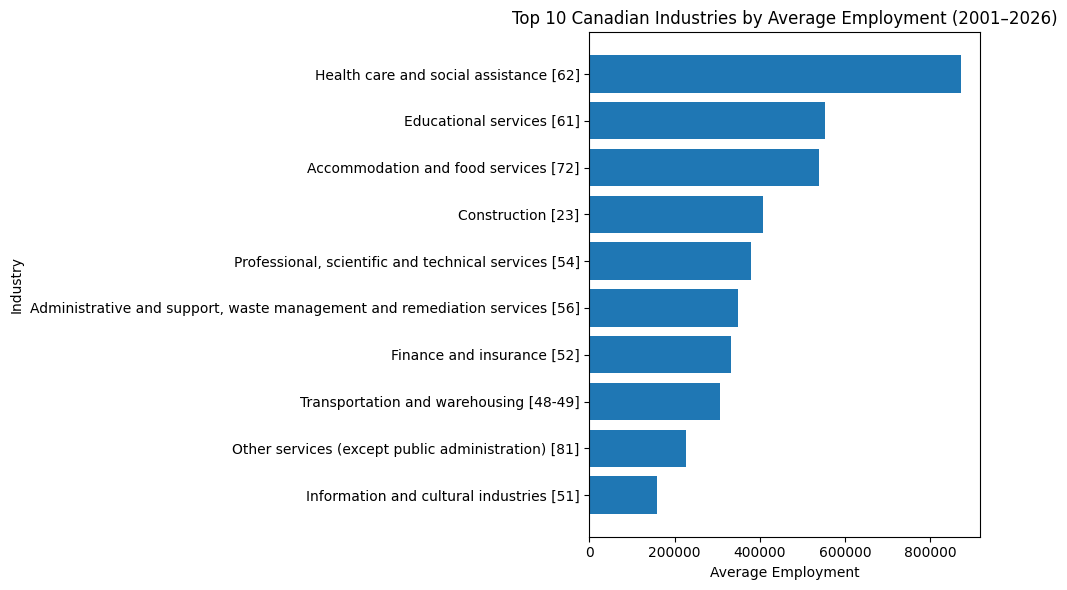

In [333]:
top10 = industry_avg.dropna().head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top10.index, top10.values)

plt.xlabel("Average Employment")
plt.ylabel("Industry")
plt.title("Top 10 Canadian Industries by Average Employment (2001–2026)")

plt.tight_layout()
plt.show()

In [334]:
# EDA 3: Employment growth by industry

# Exclude aggregate/overlapping categories
exclude = [
    "Industrial aggregate excluding unclassified businesses [11-91N]",
    "Service producing industries [41-91N]",
    "Goods producing industries [11-33N]",
    "Trade [41-45N]",
    "Manufacturing [31-33]",
    "Durable goods [321N]",
    "Non-durable goods [311N]",
    "Wholesale trade [41]",
    "Retail trade [44-45]"
]

industry_growth = df_wide[
    ~df_wide["North American Industry Classification System (NAICS)"].isin(exclude)
]

# Get employment in 2001 and 2026 for each industry
start = (
    industry_growth[industry_growth["REF_DATE"].dt.year == 2001]
    .groupby("North American Industry Classification System (NAICS)")["Employment"]
    .mean()
)

end = (
    industry_growth[industry_growth["REF_DATE"].dt.year == 2026]
    .groupby("North American Industry Classification System (NAICS)")["Employment"]
    .mean()
)

# Combine the beginning and ending employment
growth = pd.DataFrame({
    "Employment_2001": start,
    "Employment_2026": end
})

# Calculate absolute employment growth
growth["Employment_Growth"] = (
    growth["Employment_2026"] - growth["Employment_2001"]
)

# Calculate percentage growth
growth["Growth_Percent"] = (
    growth["Employment_Growth"] / growth["Employment_2001"]
) * 100

# Sort by absolute employment growth
growth = growth.sort_values("Employment_Growth", ascending=False)

growth.head(10)

,Employment_2001,Employment_2026,Employment_Growth,Growth_Percent
North American Industry Classification System (NAICS),,,,
Health care and social assistance [62],629908.125000,1.236451e+06,606542.958333,96.290702
Construction [23],241753.666667,5.610422e+05,319288.500000,132.071833
"Professional, scientific and technical services [54]",266205.583333,5.599554e+05,293749.833333,110.346984
Educational services [61],426126.333333,6.835037e+05,257377.333333,60.399303
Accommodation and food services [72],412677.583333,6.309648e+05,218287.166667,52.895329
"Administrative and support, waste management and remediation services [56]",233912.041667,3.974070e+05,163494.958333,69.895914
Transportation and warehousing [48-49],232493.125000,3.948451e+05,162351.958333,69.830864
Other services (except public administration) [81],182193.916667,2.570741e+05,74880.166667,41.099159
"Arts, entertainment and recreation [71]",91983.125000,1.592085e+05,67225.375000,73.084465


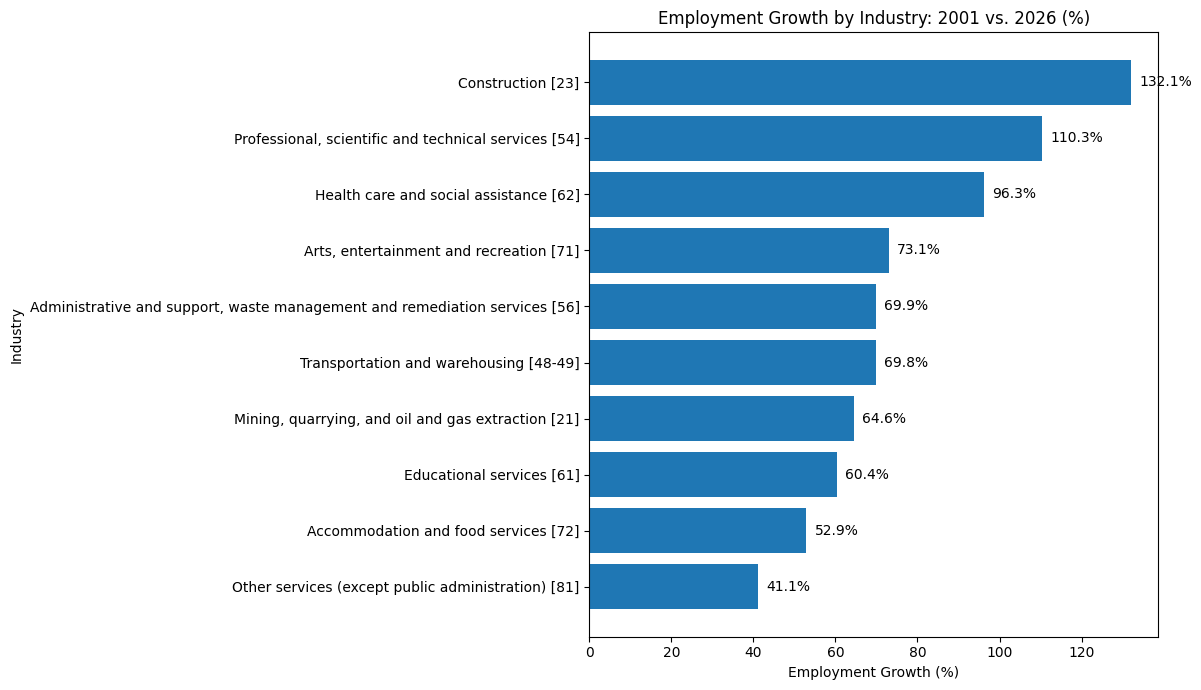

In [335]:
top10 = growth.head(10).sort_values("Growth_Percent")

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10.index,
    top10["Growth_Percent"]
)

plt.xlabel("Employment Growth (%)")
plt.ylabel("Industry")
plt.title("Employment Growth by Industry: 2001 vs. 2026 (%)")

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

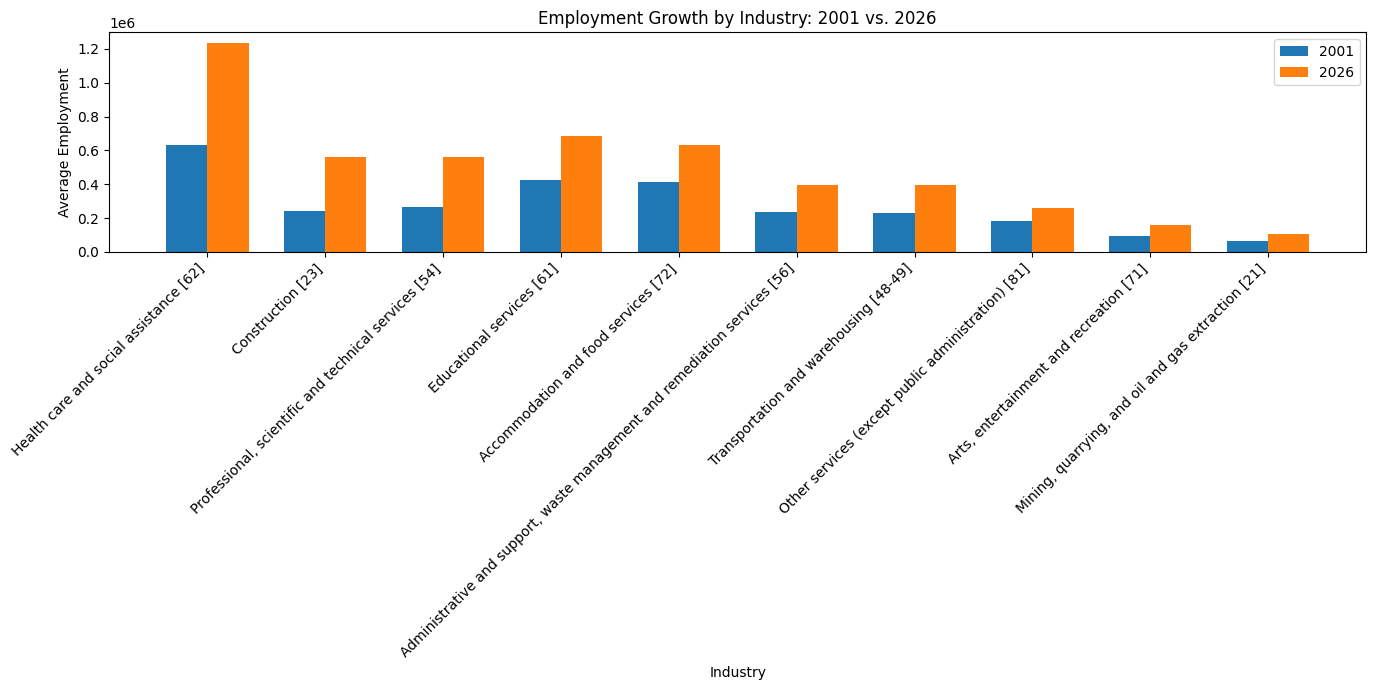

In [336]:
import matplotlib.pyplot as plt
import numpy as np

# Select the top 10 industries by employment growth
top10 = growth.head(10)

# Set positions for the industries
x = np.arange(len(top10))
width = 0.35

# Create the figure
plt.figure(figsize=(14, 7))

# Create two bars for each industry
plt.bar(
    x - width/2,
    top10["Employment_2001"],
    width,
    label="2001"
)

plt.bar(
    x + width/2,
    top10["Employment_2026"],
    width,
    label="2026"
)

# Labels and title
plt.xlabel("Industry")
plt.ylabel("Average Employment")
plt.title("Employment Growth by Industry: 2001 vs. 2026")

# Industry names on x-axis
plt.xticks(
    x,
    top10.index,
    rotation=45,
    ha="right"
)

# Add legend
plt.legend()

# Make layout cleaner
plt.tight_layout()

# Show graph
plt.show()

In [337]:
# Exclude aggregate and overlapping industry categories
exclude = [
    "Industrial aggregate excluding unclassified businesses [11-91N]",
    "Service producing industries [41-91N]",
    "Goods producing industries [11-33N]",
    "Trade [41-45N]",
    "Manufacturing [31-33]",
    "Durable goods [321N]",
    "Non-durable goods [311N]",
    "Wholesale trade [41]",
    "Retail trade [44-45]"
]

industry_earnings = df_wide[
    ~df_wide["North American Industry Classification System (NAICS)"].isin(exclude)
]

# Calculate average hourly earnings by industry
hourly_earnings = (
    industry_earnings
    .groupby(
        "North American Industry Classification System (NAICS)"
    )["Hourly_Earnings"]
    .mean()
    .sort_values(ascending=False)
)

hourly_earnings

North American Industry Classification System (NAICS)
Mining, quarrying, and oil and gas extraction [21]                            45.007827
Utilities [22]                                                                43.291792
Management of companies and enterprises [55]                                  33.439557
Professional, scientific and technical services [54]                          32.390261
Construction [23]                                                             31.808382
Information and cultural industries [51]                                      31.545698
Finance and insurance [52]                                                    30.235799
Forestry, logging and support [11N]                                           28.461377
Transportation and warehousing [48-49]                                        27.721340
Health care and social assistance [62]                                        27.359346
Real estate and rental and leasing [53]                           

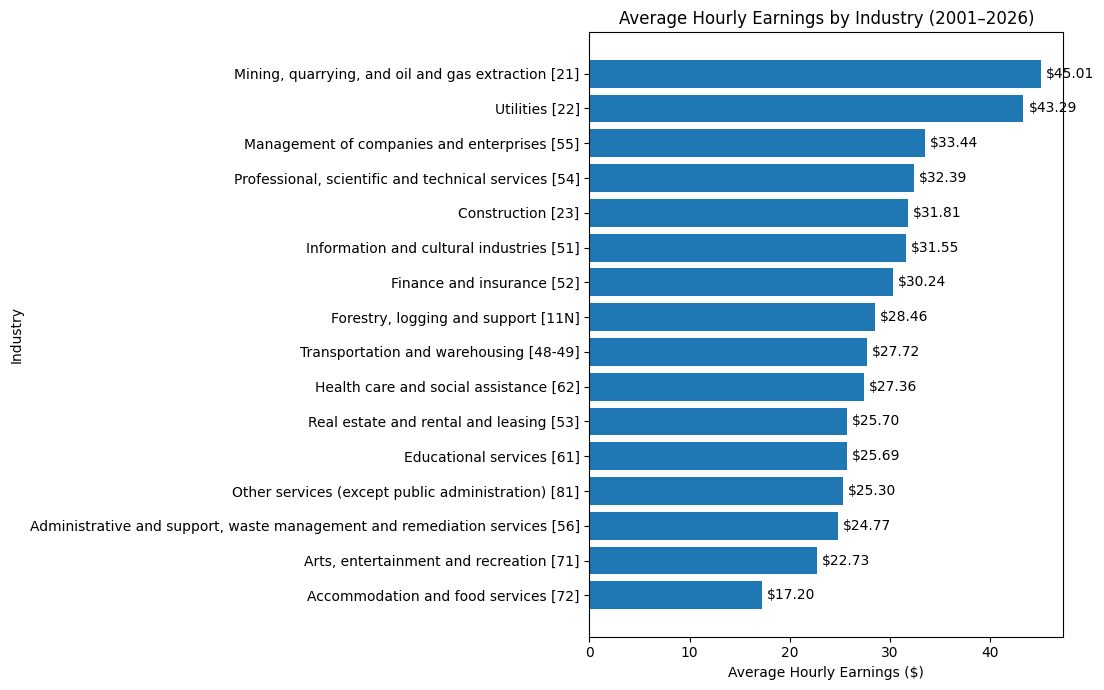

In [338]:
# Remove industries with missing earnings
hourly_earnings_clean = hourly_earnings.dropna()

# Create the chart
plt.figure(figsize=(11, 7))

bars = plt.barh(
    hourly_earnings_clean.index,
    hourly_earnings_clean.values
)

# Put highest-paid industry at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Average Hourly Earnings ($)")
plt.ylabel("Industry")
plt.title("Average Hourly Earnings by Industry (2001–2026)")

# Add values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"${width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [339]:
ml_df = df_wide[
    (df_wide["North American Industry Classification System (NAICS)"] == "Construction [23]") &
    (df_wide["Type of employee"] == "Employees paid by the hour")
].copy()

ml_df.head()

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
3,2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6
55,2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3
107,2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4
159,2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1
211,2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5


In [340]:
ml_df = ml_df.set_index("REF_DATE")

ml_df.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
REF_DATE,,,,,,,
2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6
2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3
2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4
2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1
2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5


In [341]:
ml_df["Previous_Employment"] = ml_df["Employment"].shift(1)

ml_df.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment
REF_DATE,,,,,,,,
2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6,NaN
2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3,334419.0
2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4,339243.0
2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1,345221.0
2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5,351817.0


In [342]:
ml_df["Previous_Year_Employment"] = ml_df["Employment"].shift(12)

ml_df.head(15)

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment
REF_DATE,,,,,,,,,
2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6,NaN,NaN
2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3,334419.0,NaN
2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4,339243.0,NaN
2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1,345221.0,NaN
2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5,351817.0,NaN
2001-06-01,Canada,Employees paid by the hour,Construction [23],366097.0,20.71,786.58,37.9,355131.0,NaN
2001-07-01,Canada,Employees paid by the hour,Construction [23],376102.0,20.67,781.93,37.8,366097.0,NaN
2001-08-01,Canada,Employees paid by the hour,Construction [23],383909.0,20.31,762.34,37.5,376102.0,NaN
2001-09-01,Canada,Employees paid by the hour,Construction [23],389434.0,20.30,755.10,37.3,383909.0,NaN


In [343]:
X = ml_df[
    [
        "Previous_Employment",
        "Previous_Year_Employment"
    ]
]

y = ml_df["Employment"]

print(X.head(15))
print(y.head(15))

Estimate    Previous_Employment  Previous_Year_Employment
REF_DATE                                                 
2001-01-01                  NaN                       NaN
2001-02-01             334419.0                       NaN
2001-03-01             339243.0                       NaN
2001-04-01             345221.0                       NaN
2001-05-01             351817.0                       NaN
2001-06-01             355131.0                       NaN
2001-07-01             366097.0                       NaN
2001-08-01             376102.0                       NaN
2001-09-01             383909.0                       NaN
2001-10-01             389434.0                       NaN
2001-11-01             397503.0                       NaN
2001-12-01             396980.0                       NaN
2002-01-01             403537.0                  334419.0
2002-02-01             389507.0                  339243.0
2002-03-01             382749.0                  345221.0
REF_DATE
2001-

In [344]:
ml_df = ml_df.dropna(
    subset=[
        "Previous_Employment",
        "Previous_Year_Employment",
        "Employment"
    ]
)

ml_df.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment
REF_DATE,,,,,,,,,
2002-01-01,Canada,Employees paid by the hour,Construction [23],389507.0,21.33,788.64,36.9,403537.0,334419.0
2002-02-01,Canada,Employees paid by the hour,Construction [23],382749.0,21.38,765.31,36.0,389507.0,339243.0
2002-03-01,Canada,Employees paid by the hour,Construction [23],407014.0,22.14,817.81,36.7,382749.0,345221.0
2002-04-01,Canada,Employees paid by the hour,Construction [23],408444.0,22.10,814.68,36.6,407014.0,351817.0
2002-05-01,Canada,Employees paid by the hour,Construction [23],410177.0,22.24,800.27,35.8,408444.0,355131.0


In [345]:
X = ml_df[
    [
        "Previous_Employment",
        "Previous_Year_Employment"
    ]
]

y = ml_df["Employment"]

In [346]:
X.head(10)

Estimate,Previous_Employment,Previous_Year_Employment
REF_DATE,,
2002-01-01,403537.0,334419.0
2002-02-01,389507.0,339243.0
2002-03-01,382749.0,345221.0
2002-04-01,407014.0,351817.0
2002-05-01,408444.0,355131.0
2002-06-01,410177.0,366097.0
2002-07-01,406802.0,376102.0
2002-08-01,407531.0,383909.0
2002-09-01,410723.0,389434.0


In [347]:
y.head(10)

REF_DATE
2002-01-01    389507.0
2002-02-01    382749.0
2002-03-01    407014.0
2002-04-01    408444.0
2002-05-01    410177.0
2002-06-01    406802.0
2002-07-01    407531.0
2002-08-01    410723.0
2002-09-01    412277.0
2002-10-01    416305.0
Name: Employment, dtype: float64

In [348]:
print(ml_df.shape)

(294, 9)


In [349]:
split = int(len(ml_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Testing period:", X_test.index.min(), "to", X_test.index.max())

Training rows: 235
Testing rows: 59
Training period: 2002-01-01 00:00:00 to 2021-07-01 00:00:00
Testing period: 2021-08-01 00:00:00 to 2026-06-01 00:00:00


In [350]:
from sklearn.linear_model import LinearRegression

In [351]:
model = LinearRegression()

In [352]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [353]:
y_pred = model.predict(X_test)

In [354]:
y_pred

array([778764.23292   , 789477.06916974, 780447.11195688, 798486.65612307,
       800642.73793722, 804854.94810114, 828615.77112043, 843234.25686361,
       859645.89983489, 857356.52109483, 865308.73875364, 862268.50506312,
       854900.35843587, 858621.1639785 , 874989.18235143, 857333.34181469,
       845805.41255754, 895015.96146562, 884251.74875649, 885417.37667926,
       880555.81611583, 863265.54357145, 881170.39951381, 884631.65295376,
       894421.58771025, 865383.11379381, 863174.04159326, 866461.67464816,
       875209.09891855, 874452.34590027, 871189.41261374, 883327.49269606,
       872499.37356213, 896348.30362421, 875252.2852735 , 883115.09151562,
       885695.22679694, 894656.10312079, 890132.5687959 , 885920.48559461,
       874010.16765681, 865196.02390169, 858410.50986207, 854773.84526505,
       870889.20061152, 873478.97724381, 884476.79900527, 877579.84136313,
       885257.06253647, 891359.09561521, 893348.41133156, 904461.16978566,
       914034.93294769, 9

In [355]:
print(y_pred[:10])

[778764.23292    789477.06916974 780447.11195688 798486.65612307
 800642.73793722 804854.94810114 828615.77112043 843234.25686361
 859645.89983489 857356.52109483]


In [356]:
print(y_test.iloc[:10].values)

[790658. 781042. 799478. 801904. 805515. 830257. 845170. 861723. 859580.
 867795.]


In [357]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 10136.027590418405


In [358]:
baseline_pred = X_test["Previous_Employment"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 10002.949152542373


In [359]:
ml_df["Previous_Hourly_Earnings"] = ml_df["Hourly_Earnings"].shift(1)

ml_df["Previous_Weekly_Earnings"] = ml_df["Weekly_Earnings"].shift(1)

ml_df["Previous_Weekly_Hours"] = ml_df["Weekly_Hours"].shift(1)

In [360]:
ml_df = ml_df.dropna(
    subset=[
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours",
        "Employment"
    ]
)

In [361]:
X = ml_df[
    [
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours"
    ]
]

y = ml_df["Employment"]

In [362]:
split = int(len(ml_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Testing period:", X_test.index.min(), "to", X_test.index.max())

Training rows: 234
Testing rows: 59
Training period: 2002-02-01 00:00:00 to 2021-07-01 00:00:00
Testing period: 2021-08-01 00:00:00 to 2026-06-01 00:00:00


In [363]:
mlr_model = LinearRegression()

In [364]:
mlr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [365]:
mlr_pred = mlr_model.predict(X_test)

In [366]:
mlr_mae = mean_absolute_error(y_test, mlr_pred)

print("MLR MAE:", mlr_mae)

MLR MAE: 10494.475185466012


In [367]:
from sklearn.ensemble import RandomForestRegressor

In [368]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [369]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [370]:
rf_pred = rf_model.predict(X_test)

In [371]:
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 100544.3913559322


In [372]:
print(rf_pred[:10])

[778688.    785167.595 776738.845 785971.665 786034.215 781378.735
 784285.55  782259.805 780963.2   781229.11 ]


In [373]:
print(y_test.iloc[:10].values)

[790658. 781042. 799478. 801904. 805515. 830257. 845170. 861723. 859580.
 867795.]


In [374]:
errors = abs(y_test.values - rf_pred)

print(errors[:10])
print("Average error:", errors.mean())

[11970.     4125.595 22739.155 15932.335 19480.785 48878.265 60884.45
 79463.195 78616.8   86565.89 ]
Average error: 100544.3913559322


In [375]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred,
    "Absolute_Error": errors
}, index=y_test.index)

print(results.sort_values("Absolute_Error", ascending=False).head(10))

              Actual   Predicted  Absolute_Error
REF_DATE                                        
2026-01-01  927923.0  767714.055      160208.945
2025-12-01  921450.0  770060.290      151389.710
2025-11-01  916465.0  769950.205      146514.795
2025-10-01  906413.0  769959.515      136453.485
2026-02-01  905493.0  770009.070      135483.930
2026-03-01  904340.0  769950.205      134389.795
2026-06-01  904191.0  769950.205      134240.795
2026-05-01  903896.0  769854.650      134041.350
2024-04-01  897896.0  767765.910      130130.090
2026-04-01  899489.0  769824.925      129664.075


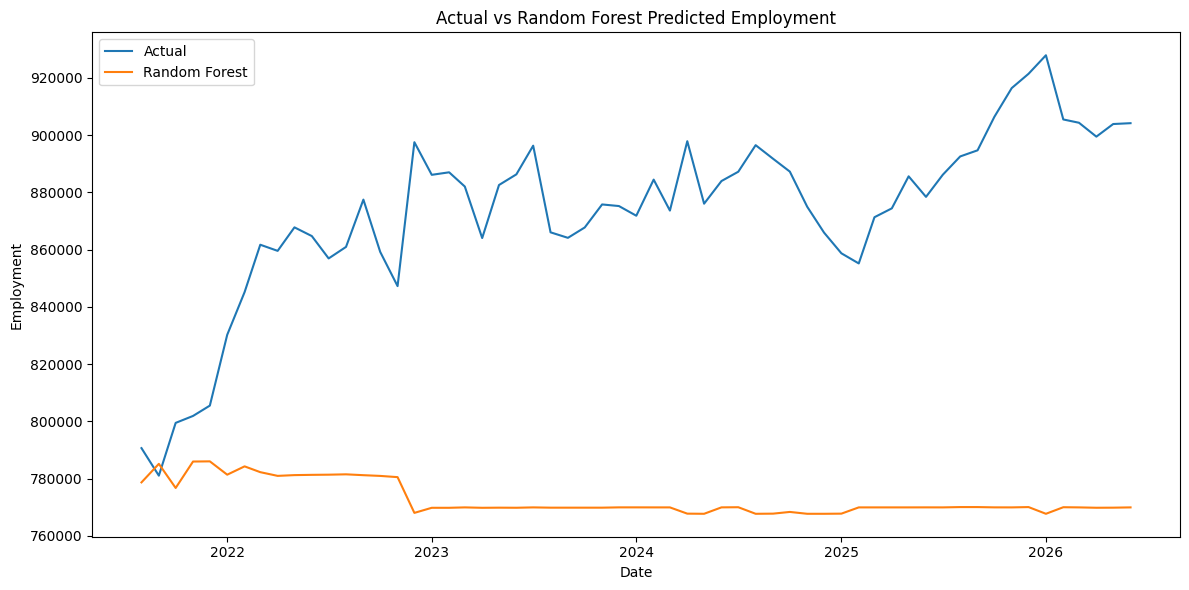

In [376]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, rf_pred, label="Random Forest")

plt.xlabel("Date")
plt.ylabel("Employment")
plt.title("Actual vs Random Forest Predicted Employment")
plt.legend()

plt.tight_layout()
plt.show()

In [377]:
ml_df["Time_Index"] = range(len(ml_df))

In [378]:
print(ml_df[["Time_Index", "Employment"]].head())

Estimate    Time_Index  Employment
REF_DATE                          
2002-02-01           0    382749.0
2002-03-01           1    407014.0
2002-04-01           2    408444.0
2002-05-01           3    410177.0
2002-06-01           4    406802.0


In [379]:
X = ml_df[
    [
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours",
        "Time_Index"
    ]
]

y = ml_df["Employment"]

In [380]:
split = int(len(ml_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 234
Testing rows: 59


In [381]:
from sklearn.linear_model import Ridge

In [382]:
ridge_model = Ridge(alpha=1.0)

In [383]:
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge Regression MAE:", ridge_mae)

Ridge Regression MAE: 9767.276080058191


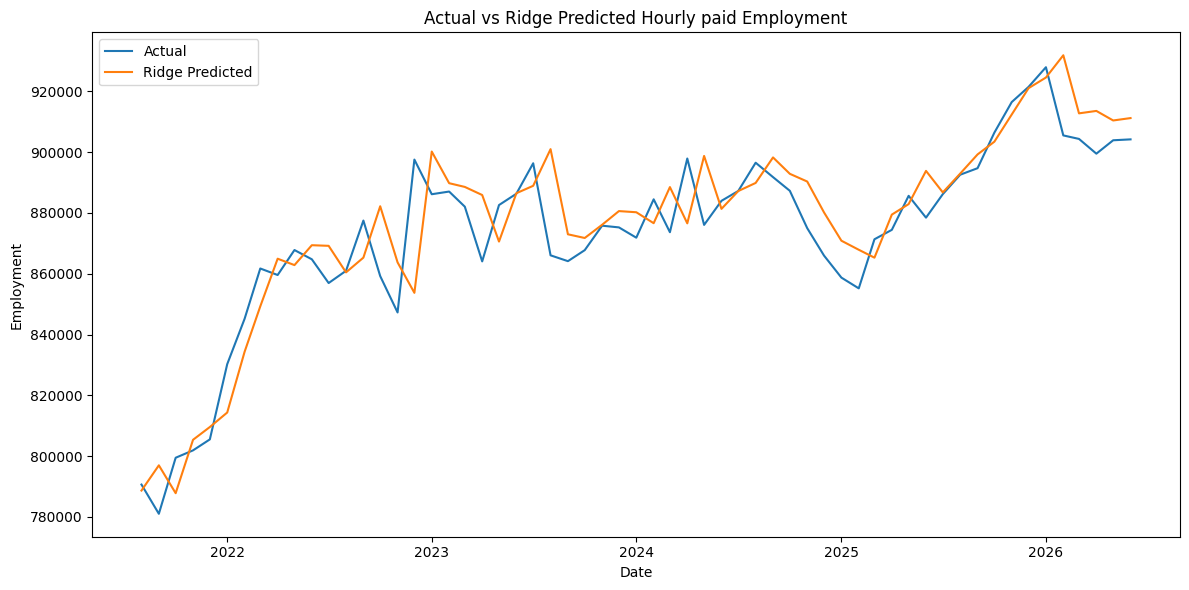

In [384]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, ridge_pred, label="Ridge Predicted")

plt.xlabel("Date")
plt.ylabel("Employment")
plt.title("Actual vs Ridge Predicted Hourly paid Employment")
plt.legend()

plt.tight_layout()
plt.show()

In [387]:
ml_df1 = df_wide[
    (df_wide["North American Industry Classification System (NAICS)"] == "Construction [23]") &
    (df_wide["Type of employee"] == "Employees paid by the hour")
].copy()

ml_df1.head()

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
3,2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6
55,2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3
107,2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4
159,2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1
211,2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5


In [389]:
ml_df1 = ml_df1.set_index("REF_DATE")

ml_df1.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
REF_DATE,,,,,,,
2001-01-01,Canada,Employees paid by the hour,Construction [23],334419.0,21.00,792.94,37.6
2001-02-01,Canada,Employees paid by the hour,Construction [23],339243.0,21.16,783.50,37.3
2001-03-01,Canada,Employees paid by the hour,Construction [23],345221.0,20.77,778.18,37.4
2001-04-01,Canada,Employees paid by the hour,Construction [23],351817.0,20.99,788.68,37.1
2001-05-01,Canada,Employees paid by the hour,Construction [23],355131.0,21.05,793.35,37.5


In [390]:
ml_df1["Previous_Employment"] = ml_df1["Employment"].shift(1)

In [391]:
ml_df1 = ml_df.dropna()

In [392]:
ml_df1.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours,Time_Index
REF_DATE,,,,,,,,,,,,,
2002-02-01,Canada,Employees paid by the hour,Construction [23],382749.0,21.38,765.31,36.0,389507.0,339243.0,21.33,788.64,36.9,0
2002-03-01,Canada,Employees paid by the hour,Construction [23],407014.0,22.14,817.81,36.7,382749.0,345221.0,21.38,765.31,36.0,1
2002-04-01,Canada,Employees paid by the hour,Construction [23],408444.0,22.10,814.68,36.6,407014.0,351817.0,22.14,817.81,36.7,2
2002-05-01,Canada,Employees paid by the hour,Construction [23],410177.0,22.24,800.27,35.8,408444.0,355131.0,22.10,814.68,36.6,3
2002-06-01,Canada,Employees paid by the hour,Construction [23],406802.0,22.19,797.44,35.9,410177.0,366097.0,22.24,800.27,35.8,4


In [393]:
ml_df1["Previous_Year_Employment"] = ml_df1["Employment"].shift(12)

In [394]:
ml_df1.head(15)

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours,Time_Index
REF_DATE,,,,,,,,,,,,,
2002-02-01,Canada,Employees paid by the hour,Construction [23],382749.0,21.38,765.31,36.0,389507.0,NaN,21.33,788.64,36.9,0
2002-03-01,Canada,Employees paid by the hour,Construction [23],407014.0,22.14,817.81,36.7,382749.0,NaN,21.38,765.31,36.0,1
2002-04-01,Canada,Employees paid by the hour,Construction [23],408444.0,22.10,814.68,36.6,407014.0,NaN,22.14,817.81,36.7,2
2002-05-01,Canada,Employees paid by the hour,Construction [23],410177.0,22.24,800.27,35.8,408444.0,NaN,22.10,814.68,36.6,3
2002-06-01,Canada,Employees paid by the hour,Construction [23],406802.0,22.19,797.44,35.9,410177.0,NaN,22.24,800.27,35.8,4
2002-07-01,Canada,Employees paid by the hour,Construction [23],407531.0,22.56,804.08,35.6,406802.0,NaN,22.19,797.44,35.9,5
2002-08-01,Canada,Employees paid by the hour,Construction [23],410723.0,22.32,796.65,35.6,407531.0,NaN,22.56,804.08,35.6,6
2002-09-01,Canada,Employees paid by the hour,Construction [23],412277.0,22.40,809.38,36.1,410723.0,NaN,22.32,796.65,35.6,7
2002-10-01,Canada,Employees paid by the hour,Construction [23],416305.0,22.26,824.92,36.9,412277.0,NaN,22.40,809.38,36.1,8


In [395]:
ml_df1 = ml_df1.dropna()

In [396]:
ml_df1.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours,Time_Index
REF_DATE,,,,,,,,,,,,,
2003-02-01,Canada,Employees paid by the hour,Construction [23],421284.0,22.14,826.54,37.5,423408.0,382749.0,22.48,846.62,37.6,12
2003-03-01,Canada,Employees paid by the hour,Construction [23],409454.0,22.14,813.03,36.8,421284.0,407014.0,22.14,826.54,37.5,13
2003-04-01,Canada,Employees paid by the hour,Construction [23],401445.0,22.12,820.86,36.6,409454.0,408444.0,22.14,813.03,36.8,14
2003-05-01,Canada,Employees paid by the hour,Construction [23],406329.0,21.45,799.35,37.1,401445.0,410177.0,22.12,820.86,36.6,15
2003-06-01,Canada,Employees paid by the hour,Construction [23],406108.0,22.10,815.87,36.9,406329.0,406802.0,21.45,799.35,37.1,16


In [397]:
ml_df1["Previous_Hourly_Earnings"] = ml_df1["Hourly_Earnings"].shift(1)

ml_df1["Previous_Weekly_Earnings"] = ml_df1["Weekly_Earnings"].shift(1)

ml_df1["Previous_Weekly_Hours"] = ml_df1["Weekly_Hours"].shift(1)

In [398]:
ml_df1 = ml_df1.dropna()

In [399]:
ml_df1

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours,Time_Index
REF_DATE,,,,,,,,,,,,,
2003-03-01,Canada,Employees paid by the hour,Construction [23],409454.0,22.14,813.03,36.8,421284.0,407014.0,22.14,826.54,37.5,13
2003-04-01,Canada,Employees paid by the hour,Construction [23],401445.0,22.12,820.86,36.6,409454.0,408444.0,22.14,813.03,36.8,14
2003-05-01,Canada,Employees paid by the hour,Construction [23],406329.0,21.45,799.35,37.1,401445.0,410177.0,22.12,820.86,36.6,15
2003-06-01,Canada,Employees paid by the hour,Construction [23],406108.0,22.10,815.87,36.9,406329.0,406802.0,21.45,799.35,37.1,16
2003-07-01,Canada,Employees paid by the hour,Construction [23],402354.0,21.86,823.03,37.6,406108.0,407531.0,22.10,815.87,36.9,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01,Canada,Employees paid by the hour,Construction [23],905493.0,39.78,1490.89,37.5,927923.0,855185.0,39.63,1467.49,37.1,288
2026-03-01,Canada,Employees paid by the hour,Construction [23],904340.0,40.32,1526.66,37.8,905493.0,871335.0,39.78,1490.89,37.5,289
2026-04-01,Canada,Employees paid by the hour,Construction [23],899489.0,40.38,1543.37,38.2,904340.0,874433.0,40.32,1526.66,37.8,290


In [400]:
X1 = ml_df1[
    [
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours"
    ]
]

y1 = ml_df1["Employment"]

In [401]:
split = int(len(ml_df1) * 0.8)

X1_train = X1.iloc[:split]
X1_test = X1.iloc[split:]

y1_train = y1.iloc[:split]
y1_test = y1.iloc[split:]

In [402]:
baseline_predictions = np.full(len(y1_test), y1_train.mean())

baseline_mae = mean_absolute_error(y1_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y1_test, baseline_predictions))
baseline_r2 = r2_score(y1_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 238372.55357142858
Baseline RMSE: 239561.50574666026
Baseline R²: -99.99542509360589


In [403]:
lr_model = LinearRegression()

lr_model.fit(X1_train, y1_train)

lr_predictions = lr_model.predict(X1_test)

lr_mae = mean_absolute_error(y1_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y1_test, lr_predictions))
lr_r2 = r2_score(y1_test, lr_predictions)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

Linear Regression MAE: 10686.230892828016
Linear Regression RMSE: 13809.929019372832
Linear Regression R²: 0.6643779189312088


In [405]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X1_train, y1_train)

ridge_predictions = ridge_model.predict(X1_test)

ridge_mae = mean_absolute_error(y1_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y1_test, ridge_predictions))
ridge_r2 = r2_score(y1_test, ridge_predictions)

print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MAE: 10669.207109547275
Ridge Regression RMSE: 13798.196727812096
Ridge Regression R²: 0.6649479354017432


In [406]:
coefficients = pd.DataFrame({
    "Feature": X1.columns,
    "Coefficient": ridge_model.coef_
})

coefficients

,Feature,Coefficient
0,Previous_Employment,0.907853
1,Previous_Year_Employment,-0.020728
2,Previous_Hourly_Earnings,-797.839703
3,Previous_Weekly_Earnings,105.411827
4,Previous_Weekly_Hours,375.743574


In [407]:
results = pd.DataFrame({
    "Actual_Employment": y1_test,
    "Predicted_Employment": ridge_predictions
})

results.head(10)

,Actual_Employment,Predicted_Employment
REF_DATE,,
2021-11-01,801904.0,805840.112242
2021-12-01,805515.0,810076.728748
2022-01-01,830257.0,816135.549207
2022-02-01,845170.0,834541.112772
2022-03-01,861723.0,850148.416126
2022-04-01,859580.0,866629.246852
2022-05-01,867795.0,862431.674391
2022-06-01,864748.0,869004.845188
2022-07-01,856937.0,869628.052488


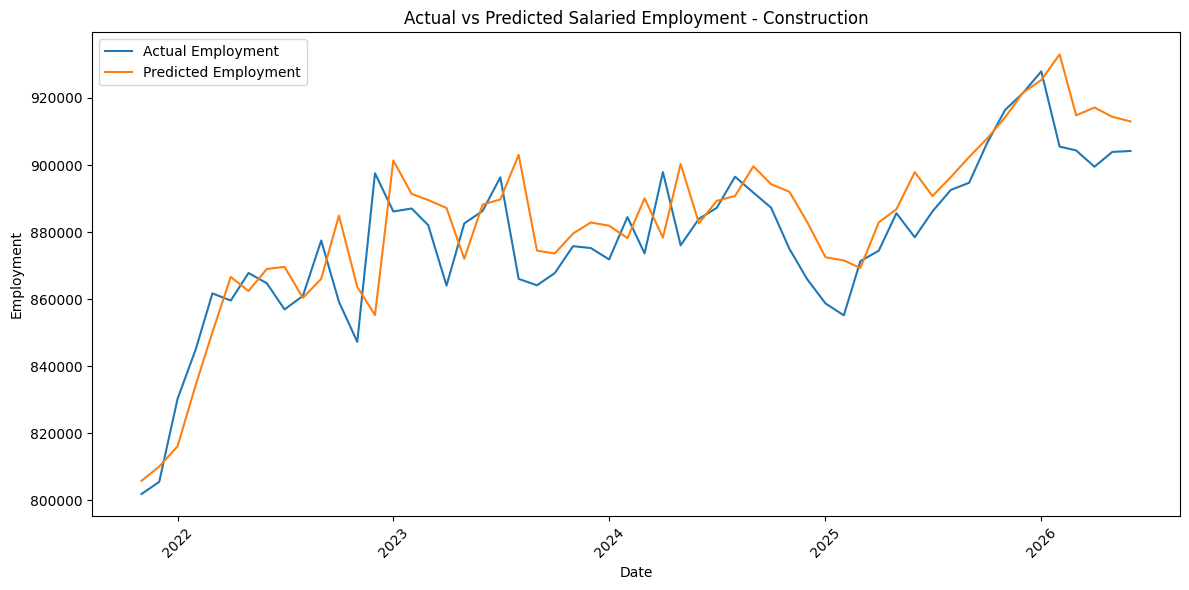

In [408]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    results.index,
    results["Actual_Employment"],
    label="Actual Employment"
)

plt.plot(
    results.index,
    results["Predicted_Employment"],
    label="Predicted Employment"
)

plt.xlabel("Date")
plt.ylabel("Employment")
plt.title("Actual vs Predicted Salaried Employment - Construction")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [412]:
ml_df_mining_hourly = df_wide[
    (df_wide["North American Industry Classification System (NAICS)"] == "Mining, quarrying, and oil and gas extraction [21]") &
    (df_wide["Type of employee"] == "Employees paid by the hour")
].copy()

ml_df_mining_hourly.head()

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
14,2001-01-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",59378.0,24.92,1007.61,40.2
66,2001-02-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",58147.0,24.69,978.66,39.5
118,2001-03-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",56975.0,24.21,966.51,39.9
170,2001-04-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",52142.0,24.68,996.41,39.9
222,2001-05-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",60367.0,23.96,965.06,40.6


In [413]:
ml_df_mining_hourly = ml_df_mining_hourly.set_index("REF_DATE")

ml_df_mining_hourly.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
REF_DATE,,,,,,,
2001-01-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",59378.0,24.92,1007.61,40.2
2001-02-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",58147.0,24.69,978.66,39.5
2001-03-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",56975.0,24.21,966.51,39.9
2001-04-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",52142.0,24.68,996.41,39.9
2001-05-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",60367.0,23.96,965.06,40.6


In [414]:
ml_df_mining_hourly["Previous_Employment"] = ml_df_mining_hourly["Employment"].shift(1)
ml_df_mining_hourly["Previous_Year_Employment"] = ml_df_mining_hourly["Employment"].shift(12)
ml_df_mining_hourly["Previous_Hourly_Earnings"] = ml_df_mining_hourly["Hourly_Earnings"].shift(1)
ml_df_mining_hourly["Previous_Weekly_Earnings"] = ml_df_mining_hourly["Weekly_Earnings"].shift(1)
ml_df_mining_hourly["Previous_Weekly_Hours"] = ml_df_mining_hourly["Weekly_Hours"].shift(1)

ml_df_mining_hourly.head(15)

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,,,,,,,,
2001-01-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",59378.0,24.92,1007.61,40.2,NaN,NaN,NaN,NaN,NaN
2001-02-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",58147.0,24.69,978.66,39.5,59378.0,NaN,24.92,1007.61,40.2
2001-03-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",56975.0,24.21,966.51,39.9,58147.0,NaN,24.69,978.66,39.5
2001-04-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",52142.0,24.68,996.41,39.9,56975.0,NaN,24.21,966.51,39.9
2001-05-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",60367.0,23.96,965.06,40.6,52142.0,NaN,24.68,996.41,39.9
2001-06-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",66811.0,25.82,1053.46,41.1,60367.0,NaN,23.96,965.06,40.6
2001-07-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",69126.0,22.00,882.85,40.6,66811.0,NaN,25.82,1053.46,41.1
2001-08-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",69989.0,23.96,961.68,40.7,69126.0,NaN,22.00,882.85,40.6
2001-09-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",73121.0,25.40,1041.04,41.1,69989.0,NaN,23.96,961.68,40.7


In [415]:
ml_df_mining_hourly = ml_df_mining_hourly.dropna()

ml_df_mining_hourly.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,,,,,,,,
2002-01-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",77630.0,25.41,1007.91,39.4,74988.0,59378.0,24.91,994.72,39.7
2002-02-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",78602.0,24.45,964.92,39.2,77630.0,58147.0,25.41,1007.91,39.4
2002-03-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",78932.0,25.11,1003.06,40.0,78602.0,56975.0,24.45,964.92,39.2
2002-04-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",77205.0,23.72,954.91,39.7,78932.0,52142.0,25.11,1003.06,40.0
2002-05-01,Canada,Employees paid by the hour,"Mining, quarrying, and oil and gas extraction ...",78588.0,25.27,1019.98,40.7,77205.0,60367.0,23.72,954.91,39.7


In [416]:
X_mining_hourly = ml_df_mining_hourly[
    [
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours"
    ]
]

y_mining_hourly = ml_df_mining_hourly["Employment"]

In [418]:
X_mining_hourly.head()

Estimate,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,
2002-01-01,74988.0,59378.0,24.91,994.72,39.7
2002-02-01,77630.0,58147.0,25.41,1007.91,39.4
2002-03-01,78602.0,56975.0,24.45,964.92,39.2
2002-04-01,78932.0,52142.0,25.11,1003.06,40.0
2002-05-01,77205.0,60367.0,23.72,954.91,39.7


In [419]:
y_mining_hourly.head()

REF_DATE
2002-01-01    77630.0
2002-02-01    78602.0
2002-03-01    78932.0
2002-04-01    77205.0
2002-05-01    78588.0
Name: Employment, dtype: float64

In [420]:
split_mining_hourly = int(len(ml_df_mining_hourly) * 0.8)

X_train_mining_hourly = X_mining_hourly.iloc[:split_mining_hourly]
X_test_mining_hourly = X_mining_hourly.iloc[split_mining_hourly:]

y_train_mining_hourly = y_mining_hourly.iloc[:split_mining_hourly]
y_test_mining_hourly = y_mining_hourly.iloc[split_mining_hourly:]

print("Training rows:", len(X_train_mining_hourly))
print("Testing rows:", len(X_test_mining_hourly))
print("Training period:", X_train_mining_hourly.index.min(), "to", X_train_mining_hourly.index.max())
print("Testing period:", X_test_mining_hourly.index.min(), "to", X_test_mining_hourly.index.max())

Training rows: 235
Testing rows: 59
Training period: 2002-01-01 00:00:00 to 2021-07-01 00:00:00
Testing period: 2021-08-01 00:00:00 to 2026-06-01 00:00:00


In [421]:
baseline_predictions_mining_hourly = np.full(
    len(y_test_mining_hourly),
    y_train_mining_hourly.mean()
)

baseline_mae_mining_hourly = mean_absolute_error(
    y_test_mining_hourly,
    baseline_predictions_mining_hourly
)

baseline_rmse_mining_hourly = np.sqrt(
    mean_squared_error(
        y_test_mining_hourly,
        baseline_predictions_mining_hourly
    )
)

baseline_r2_mining_hourly = r2_score(
    y_test_mining_hourly,
    baseline_predictions_mining_hourly
)

print("Baseline MAE:", baseline_mae_mining_hourly)
print("Baseline RMSE:", baseline_rmse_mining_hourly)
print("Baseline R²:", baseline_r2_mining_hourly)

Baseline MAE: 11597.916913090508
Baseline RMSE: 13726.581177487627
Baseline R²: -1.3734668008527184


In [422]:
lr_model_mining_hourly = LinearRegression()

lr_model_mining_hourly.fit(
    X_train_mining_hourly,
    y_train_mining_hourly
)

lr_predictions_mining_hourly = lr_model_mining_hourly.predict(
    X_test_mining_hourly
)

lr_mae_mining_hourly = mean_absolute_error(
    y_test_mining_hourly,
    lr_predictions_mining_hourly
)

lr_rmse_mining_hourly = np.sqrt(
    mean_squared_error(
        y_test_mining_hourly,
        lr_predictions_mining_hourly
    )
)

lr_r2_mining_hourly = r2_score(
    y_test_mining_hourly,
    lr_predictions_mining_hourly
)

print("Linear Regression MAE:", lr_mae_mining_hourly)
print("Linear Regression RMSE:", lr_rmse_mining_hourly)
print("Linear Regression R²:", lr_r2_mining_hourly)

Linear Regression MAE: 4975.419313306735
Linear Regression RMSE: 6226.893486308466
Linear Regression R²: 0.511571193538207


In [423]:
ridge_model_mining_hourly = Ridge(alpha=1.0)

ridge_model_mining_hourly.fit(
    X_train_mining_hourly,
    y_train_mining_hourly
)

ridge_predictions_mining_hourly = ridge_model_mining_hourly.predict(
    X_test_mining_hourly
)

ridge_mae_mining_hourly = mean_absolute_error(
    y_test_mining_hourly,
    ridge_predictions_mining_hourly
)

ridge_rmse_mining_hourly = np.sqrt(
    mean_squared_error(
        y_test_mining_hourly,
        ridge_predictions_mining_hourly
    )
)

ridge_r2_mining_hourly = r2_score(
    y_test_mining_hourly,
    ridge_predictions_mining_hourly
)

print("Ridge Regression MAE:", ridge_mae_mining_hourly)
print("Ridge Regression RMSE:", ridge_rmse_mining_hourly)
print("Ridge Regression R²:", ridge_r2_mining_hourly)

Ridge Regression MAE: 4958.747256186937
Ridge Regression RMSE: 6210.098144812594
Ridge Regression R²: 0.5142024463456393


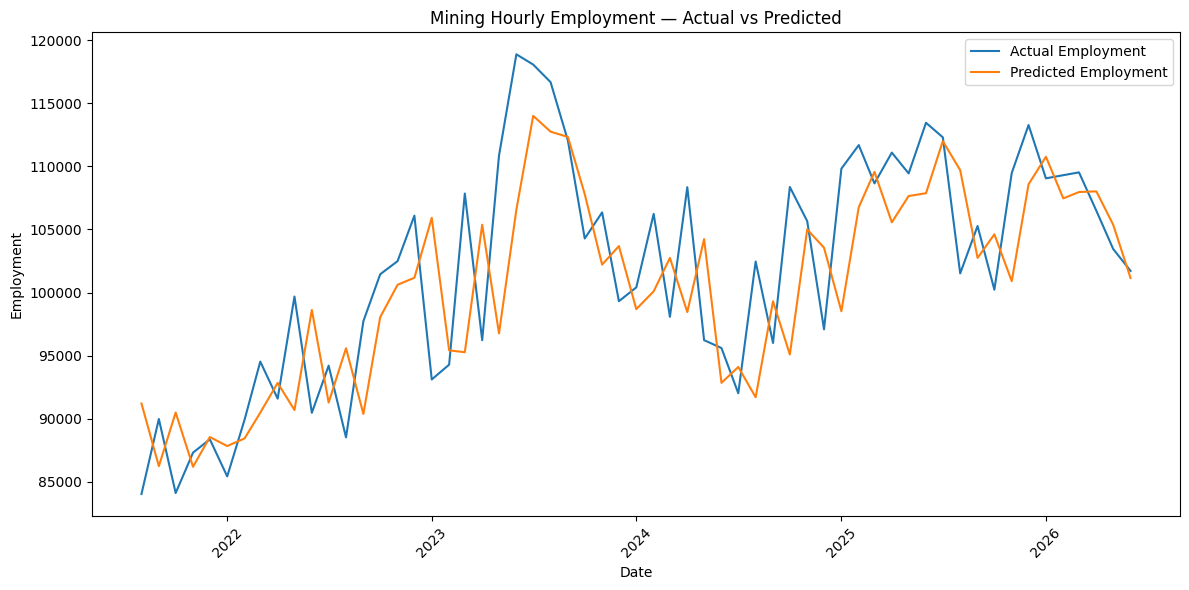

In [424]:
results_mining_hourly = pd.DataFrame({
    "Actual_Employment": y_test_mining_hourly,
    "Predicted_Employment": ridge_predictions_mining_hourly
})

plt.figure(figsize=(12, 6))

plt.plot(
    results_mining_hourly.index,
    results_mining_hourly["Actual_Employment"],
    label="Actual Employment"
)

plt.plot(
    results_mining_hourly.index,
    results_mining_hourly["Predicted_Employment"],
    label="Predicted Employment"
)

plt.title("Mining Hourly Employment — Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Employment")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [425]:
ml_df_mining_salaried = df_wide[
    (df_wide["North American Industry Classification System (NAICS)"] == "Mining, quarrying, and oil and gas extraction [21]") &
    (df_wide["Type of employee"] == "Salaried employees paid a fixed salary")
].copy()

ml_df_mining_salaried.head()

Estimate,REF_DATE,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
40,2001-01-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",60002.0,32.06,1269.56,39.6
92,2001-02-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",65403.0,31.48,1254.41,39.8
144,2001-03-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",71353.0,32.77,1269.03,38.7
196,2001-04-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",76944.0,32.81,1269.53,38.7
248,2001-05-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",68632.0,33.43,1268.80,38.0


In [427]:
ml_df_mining_salaried = ml_df_mining_salaried.set_index("REF_DATE")

ml_df_mining_salaried.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours
REF_DATE,,,,,,,
2001-01-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",60002.0,32.06,1269.56,39.6
2001-02-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",65403.0,31.48,1254.41,39.8
2001-03-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",71353.0,32.77,1269.03,38.7
2001-04-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",76944.0,32.81,1269.53,38.7
2001-05-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",68632.0,33.43,1268.80,38.0


In [428]:
ml_df_mining_salaried["Previous_Employment"] = ml_df_mining_salaried["Employment"].shift(1)
ml_df_mining_salaried["Previous_Year_Employment"] = ml_df_mining_salaried["Employment"].shift(12)
ml_df_mining_salaried["Previous_Hourly_Earnings"] = ml_df_mining_salaried["Hourly_Earnings"].shift(1)
ml_df_mining_salaried["Previous_Weekly_Earnings"] = ml_df_mining_salaried["Weekly_Earnings"].shift(1)
ml_df_mining_salaried["Previous_Weekly_Hours"] = ml_df_mining_salaried["Weekly_Hours"].shift(1)

ml_df_mining_salaried.head(15)

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,,,,,,,,
2001-01-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",60002.0,32.06,1269.56,39.6,NaN,NaN,NaN,NaN,NaN
2001-02-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",65403.0,31.48,1254.41,39.8,60002.0,NaN,32.06,1269.56,39.6
2001-03-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",71353.0,32.77,1269.03,38.7,65403.0,NaN,31.48,1254.41,39.8
2001-04-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",76944.0,32.81,1269.53,38.7,71353.0,NaN,32.77,1269.03,38.7
2001-05-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",68632.0,33.43,1268.80,38.0,76944.0,NaN,32.81,1269.53,38.7
2001-06-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",64034.0,32.94,1270.63,38.6,68632.0,NaN,33.43,1268.80,38.0
2001-07-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",59995.0,34.93,1432.75,41.0,64034.0,NaN,32.94,1270.63,38.6
2001-08-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",57006.0,37.15,1517.84,40.9,59995.0,NaN,34.93,1432.75,41.0
2001-09-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",55926.0,37.36,1496.22,40.0,57006.0,NaN,37.15,1517.84,40.9


In [429]:
ml_df_mining_salaried = ml_df_mining_salaried.dropna()

ml_df_mining_salaried.head()

Estimate,GEO,Type of employee,North American Industry Classification System (NAICS),Employment,Hourly_Earnings,Weekly_Earnings,Weekly_Hours,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,,,,,,,,
2002-01-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",52267.0,33.88,1394.53,41.2,54162.0,60002.0,31.80,1253.81,39.4
2002-02-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",53065.0,33.19,1333.67,40.2,52267.0,65403.0,33.88,1394.53,41.2
2002-03-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",53202.0,34.98,1448.79,41.4,53065.0,71353.0,33.19,1333.67,40.2
2002-04-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",56594.0,32.64,1331.60,40.8,53202.0,76944.0,34.98,1448.79,41.4
2002-05-01,Canada,Salaried employees paid a fixed salary,"Mining, quarrying, and oil and gas extraction ...",58495.0,32.81,1345.86,41.0,56594.0,68632.0,32.64,1331.60,40.8


In [430]:
X_mining_salaried = ml_df_mining_salaried[
    [
        "Previous_Employment",
        "Previous_Year_Employment",
        "Previous_Hourly_Earnings",
        "Previous_Weekly_Earnings",
        "Previous_Weekly_Hours"
    ]
]

y_mining_salaried = ml_df_mining_salaried["Employment"]

In [431]:
X_mining_salaried.head()

Estimate,Previous_Employment,Previous_Year_Employment,Previous_Hourly_Earnings,Previous_Weekly_Earnings,Previous_Weekly_Hours
REF_DATE,,,,,
2002-01-01,54162.0,60002.0,31.80,1253.81,39.4
2002-02-01,52267.0,65403.0,33.88,1394.53,41.2
2002-03-01,53065.0,71353.0,33.19,1333.67,40.2
2002-04-01,53202.0,76944.0,34.98,1448.79,41.4
2002-05-01,56594.0,68632.0,32.64,1331.60,40.8


In [432]:
y_mining_salaried.head()

REF_DATE
2002-01-01    52267.0
2002-02-01    53065.0
2002-03-01    53202.0
2002-04-01    56594.0
2002-05-01    58495.0
Name: Employment, dtype: float64

In [433]:
split_mining_salaried = int(len(ml_df_mining_salaried) * 0.8)

X_train_mining_salaried = X_mining_salaried.iloc[:split_mining_salaried]
X_test_mining_salaried = X_mining_salaried.iloc[split_mining_salaried:]

y_train_mining_salaried = y_mining_salaried.iloc[:split_mining_salaried]
y_test_mining_salaried = y_mining_salaried.iloc[split_mining_salaried:]

print("Training rows:", len(X_train_mining_salaried))
print("Testing rows:", len(X_test_mining_salaried))
print("Training period:", X_train_mining_salaried.index.min(), "to", X_train_mining_salaried.index.max())
print("Testing period:", X_test_mining_salaried.index.min(), "to", X_test_mining_salaried.index.max())

Training rows: 235
Testing rows: 59
Training period: 2002-01-01 00:00:00 to 2021-07-01 00:00:00
Testing period: 2021-08-01 00:00:00 to 2026-06-01 00:00:00


In [434]:
baseline_predictions_mining_salaried = np.full(
    len(y_test_mining_salaried),
    y_train_mining_salaried.mean()
)

baseline_mae_mining_salaried = mean_absolute_error(
    y_test_mining_salaried,
    baseline_predictions_mining_salaried
)

baseline_rmse_mining_salaried = np.sqrt(
    mean_squared_error(
        y_test_mining_salaried,
        baseline_predictions_mining_salaried
    )
)

baseline_r2_mining_salaried = r2_score(
    y_test_mining_salaried,
    baseline_predictions_mining_salaried
)

print("Baseline MAE:", baseline_mae_mining_salaried)
print("Baseline RMSE:", baseline_rmse_mining_salaried)
print("Baseline R²:", baseline_r2_mining_salaried)

Baseline MAE: 11929.16336098088
Baseline RMSE: 13588.466923203408
Baseline R²: -3.0451949792301365


In [435]:
lr_model_mining_salaried = LinearRegression()

lr_model_mining_salaried.fit(
    X_train_mining_salaried,
    y_train_mining_salaried
)

lr_predictions_mining_salaried = lr_model_mining_salaried.predict(
    X_test_mining_salaried
)

lr_mae_mining_salaried = mean_absolute_error(
    y_test_mining_salaried,
    lr_predictions_mining_salaried
)

lr_rmse_mining_salaried = np.sqrt(
    mean_squared_error(
        y_test_mining_salaried,
        lr_predictions_mining_salaried
    )
)

lr_r2_mining_salaried = r2_score(
    y_test_mining_salaried,
    lr_predictions_mining_salaried
)

print("Linear Regression MAE:", lr_mae_mining_salaried)
print("Linear Regression RMSE:", lr_rmse_mining_salaried)
print("Linear Regression R²:", lr_r2_mining_salaried)

Linear Regression MAE: 6006.032435310331
Linear Regression RMSE: 7518.377486426649
Linear Regression R²: -0.23835964440695845


In [436]:
ridge_model_mining_salaried = Ridge(alpha=1.0)

ridge_model_mining_salaried.fit(
    X_train_mining_salaried,
    y_train_mining_salaried
)

ridge_predictions_mining_salaried = ridge_model_mining_salaried.predict(
    X_test_mining_salaried
)

ridge_mae_mining_salaried = mean_absolute_error(
    y_test_mining_salaried,
    ridge_predictions_mining_salaried
)

ridge_rmse_mining_salaried = np.sqrt(
    mean_squared_error(
        y_test_mining_salaried,
        ridge_predictions_mining_salaried
    )
)

ridge_r2_mining_salaried = r2_score(
    y_test_mining_salaried,
    ridge_predictions_mining_salaried
)

print("Ridge Regression MAE:", ridge_mae_mining_salaried)
print("Ridge Regression RMSE:", ridge_rmse_mining_salaried)
print("Ridge Regression R²:", ridge_r2_mining_salaried)

Ridge Regression MAE: 6039.9181155158185
Ridge Regression RMSE: 7522.873416061617
Ridge Regression R²: -0.23984114557329606


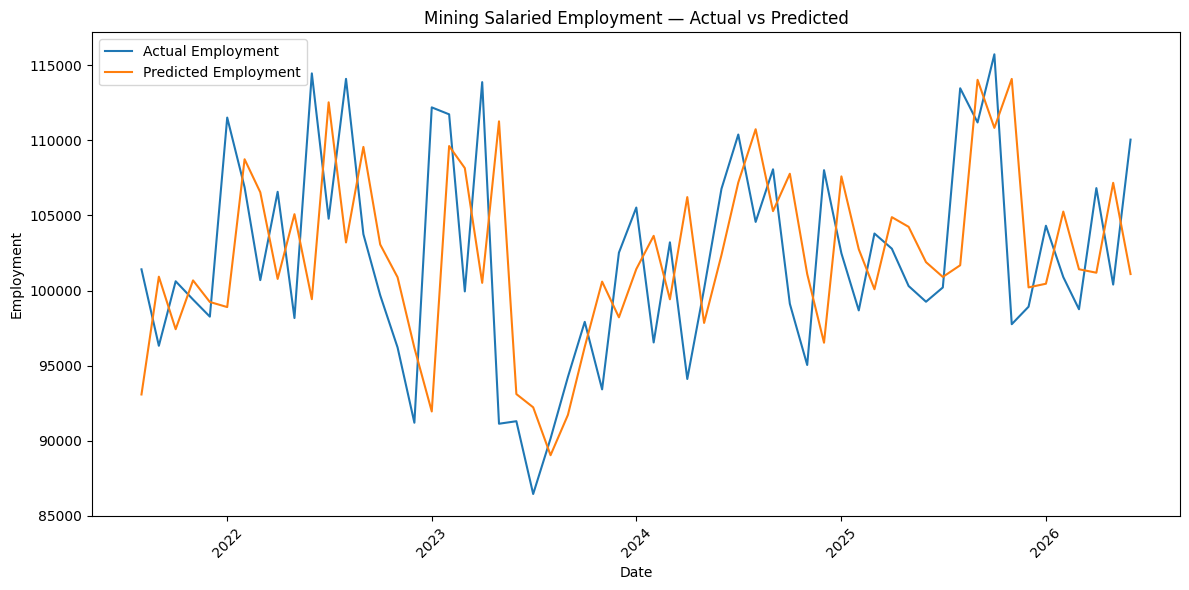

In [437]:
results_mining_salaried = pd.DataFrame({
    "Actual_Employment": y_test_mining_salaried,
    "Predicted_Employment": ridge_predictions_mining_salaried
})

plt.figure(figsize=(12, 6))

plt.plot(
    results_mining_salaried.index,
    results_mining_salaried["Actual_Employment"],
    label="Actual Employment"
)

plt.plot(
    results_mining_salaried.index,
    results_mining_salaried["Predicted_Employment"],
    label="Predicted Employment"
)

plt.title("Mining Salaried Employment — Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Employment")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [438]:
future_mining_salaried = pd.DataFrame({
    "Previous_Employment": [50000],
    "Previous_Year_Employment": [51000],
    "Previous_Hourly_Earnings": [35.00],
    "Previous_Weekly_Earnings": [1400.00],
    "Previous_Weekly_Hours": [40.0]
})

future_prediction_mining_salaried = ridge_model_mining_salaried.predict(
    future_mining_salaried
)

print("Predicted Mining Salaried Employment:", future_prediction_mining_salaried[0])

Predicted Mining Salaried Employment: 53551.45633300399
